# Basic Image classification with keras

In [1]:
# Import libraries and print TensorFlow version
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.16.2


In [2]:
# Load the Fashion MNIST dataset (grayscale 28x28 images)
fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [3]:
# Human-readable class names for the dataset labels
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

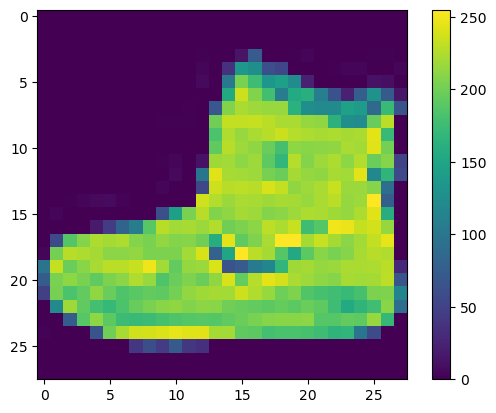

In [4]:
# Display the first training image to inspect the data
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

In [5]:
# Normalize pixel values from [0,255] to [0,1] for faster convergence
train_images = train_images / 255.0
test_images = test_images / 255.0

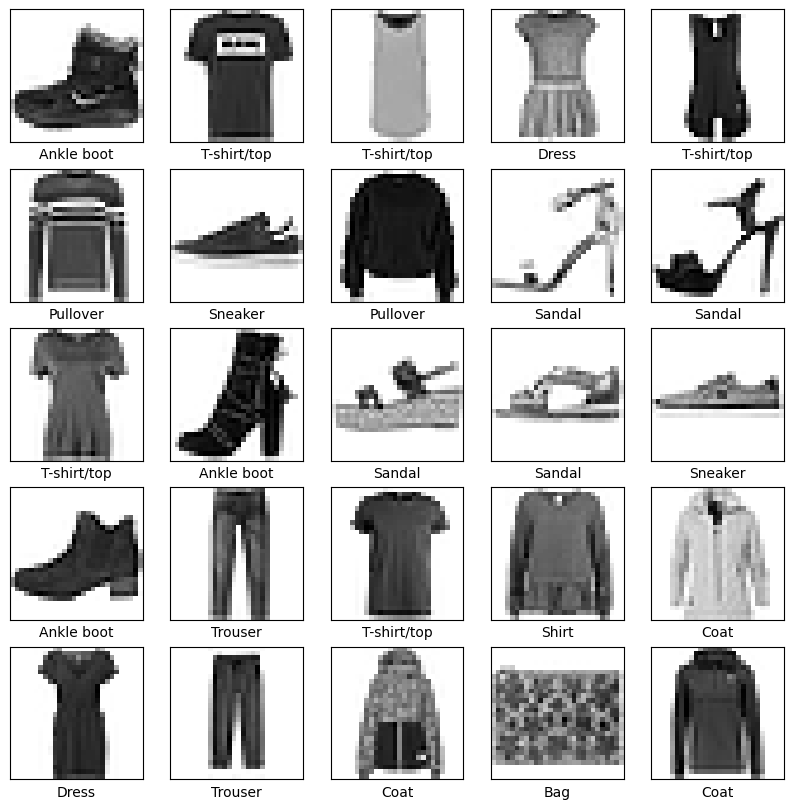

In [6]:
# Display a 5x5 grid of the first 25 training images with labels
plt.figure(figsize = (10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

In [7]:
# Define a simple Sequential neural network model
# - Flatten converts 2D image to 1D array
# - Dense 128 with ReLU is a hidden layer
# - Final Dense layer has 10 outputs (logits) for the 10 classes
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])

/opt/anaconda3/envs/Tensorflow-Metal-2025/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2025-11-11 12:47:49.075413: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-11-11 12:47:49.075451: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-11-11 12:47:49.075459: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-11-11 12:47:49.075499: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-11 12:47:49.075511: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow devic

In [8]:
# Compile the model with optimizer, loss, and evaluation metric
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Print model architecture summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Train the model on the training data for 10 epochs
model.fit(train_images, train_labels, epochs=10)

Epoch 1/10


2025-11-11 12:47:50.273189: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.8112 - loss: 0.5442
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8374 - loss: 0.4709
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8393 - loss: 0.4668
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8395 - loss: 0.4711
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8409 - loss: 0.4691
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8398 - loss: 0.4806
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8393 - loss: 0.4831
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8388 - loss: 0.4900
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8367 - loss: 0.4991
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8372 - loss: 0.5033


In [10]:
# Evaluate the trained model on the test dataset
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

print('\nTest Accuracy:', test_acc)

313/313 - 2s - 5ms/step - accuracy: 0.8131 - loss: 0.6279

Test Accuracy: 0.8130999803543091


In [11]:
# Wrap the trained model with a softmax layer so outputs become probabilities
probability_model = tf.keras.Sequential([model,
                                         tf.keras.layers.Softmax()])

In [12]:
# Compute predicted class probabilities for all test images
predictions = probability_model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [13]:
# Helper functions to visualize predictions
def plot_image(i, predictions_array, true_label, img):
  # Extract the i-th true label and image
  true_label, img = true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  # Show the image in grayscale
  plt.imshow(img, cmap=plt.cm.binary)

  # Pick the label with highest predicted probability
  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  # Label the plot with predicted class, probability and true class
  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  # Plot a bar chart of the class probabilities for the i-th image
  true_label = true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  # Highlight the predicted and true labels
  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

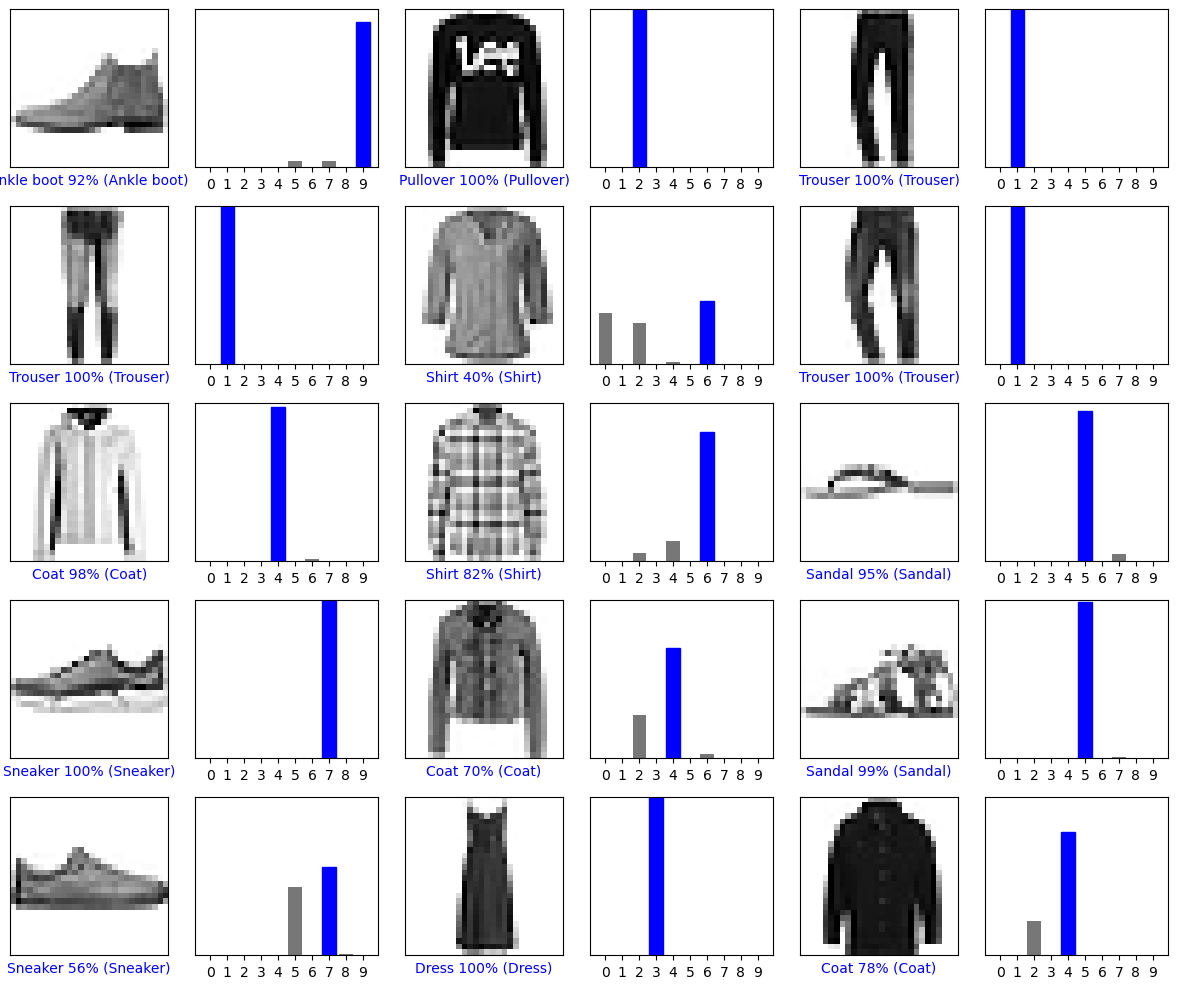

In [14]:
# Display a few test images alongside their prediction probability bars
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions[i], test_labels, test_images)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictions[i], test_labels)
plt.tight_layout()
plt.show()

## Use the trained model to make a prediction about a single image.

In [15]:
# Prepare a single image from the test set for prediction
img = test_images[1]

print(img.shape)

(28, 28)


In [16]:
# Add the image to a batch where it's the only member so the model can accept it
img = (np.expand_dims(img,0))

print(img.shape)

(1, 28, 28)


In [17]:
# Predict the class probabilities for the single image batch
predictions_single = probability_model.predict(img)

print(predictions_single)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step
[[3.9120208e-05 5.1655258e-15 9.9782145e-01 6.0350730e-10 8.3233375e-04
  1.5473298e-25 1.3070891e-03 1.1668232e-33 4.3682169e-11 0.0000000e+00]]


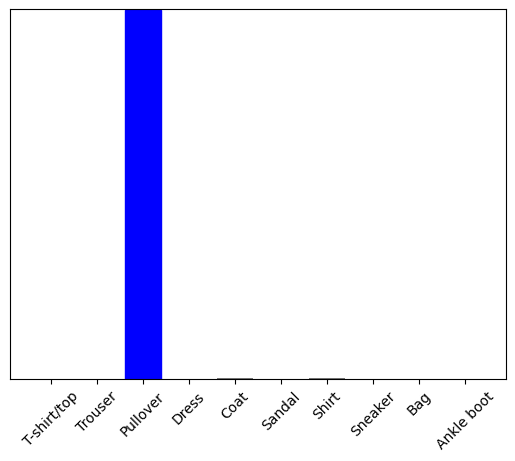

In [18]:
# Visualize the predicted probability distribution for the single image
plot_value_array(1, predictions_single[0], test_labels)
_ = plt.xticks(range(10), class_names, rotation=45)
plt.show()